In [25]:
import numpy as np   
import pandas as pd
import scanpy as sc
import seaborn as sb
from scipy import sparse
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
sc.settings.verbosity = 3         

sc.logging.print_header()            
sc.settings.set_figure_params(dpi=80,   
 dpi_save=300,fontsize=14,format='pdf',
 facecolor='none') 
plt.rcParams['pdf.fonttype'] = 42  
plt.rcParams['font.family'] = 'sans-serif'  
plt.rcParams['font.sans-serif'] = ['Arial']

scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 louvain==0.8.2 pynndescent==0.5.13


In [26]:
adata = sc.read_h5ad('GSE172261_PCA_harmony.h5ad')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


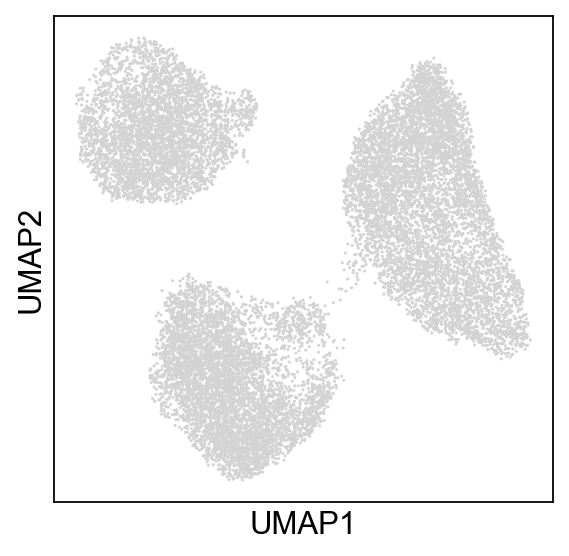

In [27]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15,n_pcs=25)#调整neighbors和pcs，最大50
sc.tl.umap(adata)
sc.pl.umap(adata)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


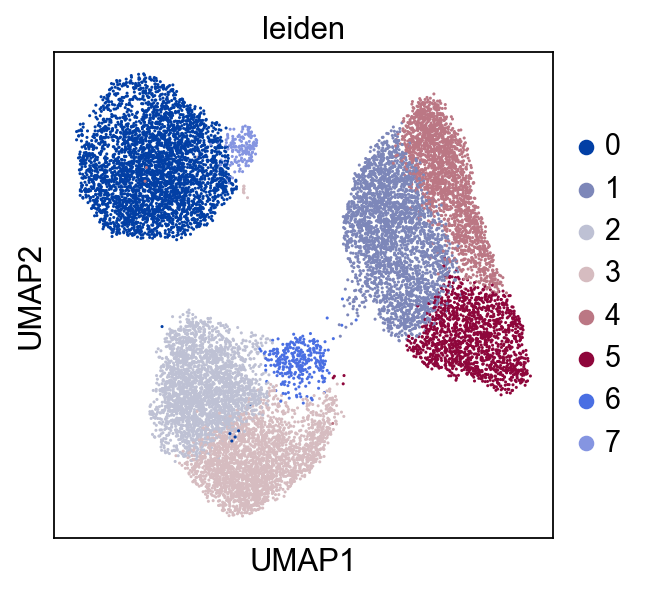

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


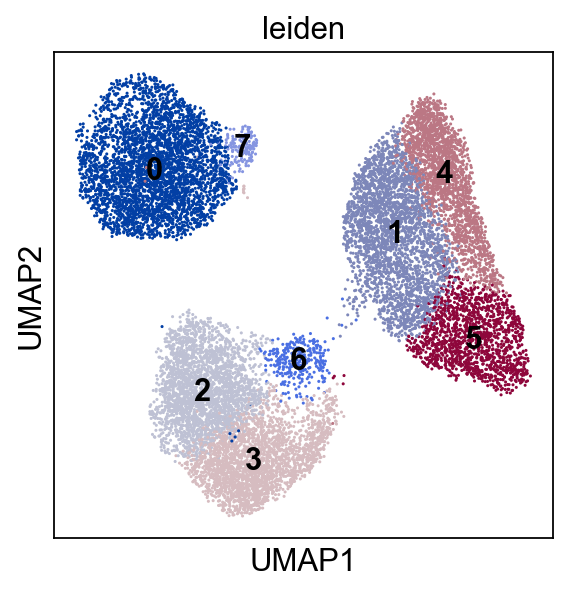

In [28]:
sc.tl.leiden(adata,resolution=0.5) 
sc.pl.umap(adata, color=['leiden'])
sc.pl.umap(adata, color=['leiden'],legend_loc='on data')

In [29]:
import scanpy as sc
import pandas as pd

groupby_key = "leiden"
reference = "rest"
method = "wilcoxon"
output_file = "DEG_leiden_result.xlsx"
sort_by = "logfoldchanges"
top_n = None

sc.tl.rank_genes_groups(
    adata,
    groupby=groupby_key,
    reference=reference,
    method=method
)

groups = adata.obs[groupby_key].astype(str).unique()

with pd.ExcelWriter(output_file) as writer:

    for g in groups:

        df = sc.get.rank_genes_groups_df(
            adata,
            group=g
        )

        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=False)

        if top_n is not None:
            df = df.head(top_n)

        sheet_name = f"{groupby_key}_{g}"[:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved DEG results to: {output_file}")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:19)
Saved DEG results to: DEG_leiden_result.xlsx


In [30]:
cluster2annotation = {
 '0': 'C3+',
 '1': 'Sox6+',
 '2': 'Serpine2+',
 '3': 'Serpine2+',
 '4': 'Sox6+',
 '5': 'Nrg1+',
 '6': 'Cd36+',
 '7': 'C3+'}

In [31]:
adata.obs['cell type'] = adata.obs['leiden'].map(cluster2annotation).astype('category')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


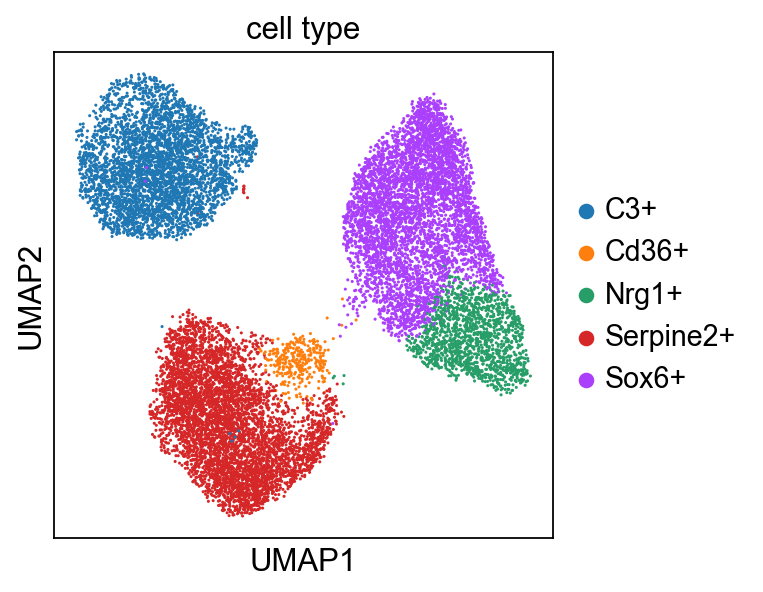

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


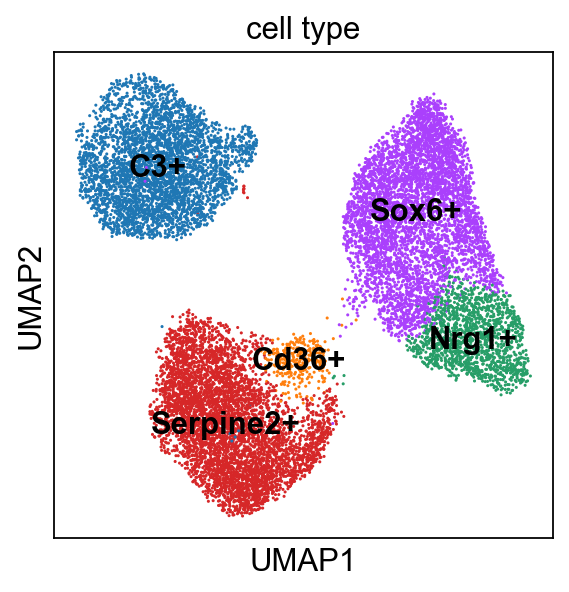

In [32]:
sc.pl.umap(adata, color=['cell type'],save='celltype.pdf')
sc.pl.umap(adata, color=['cell type'],legend_loc='on data')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


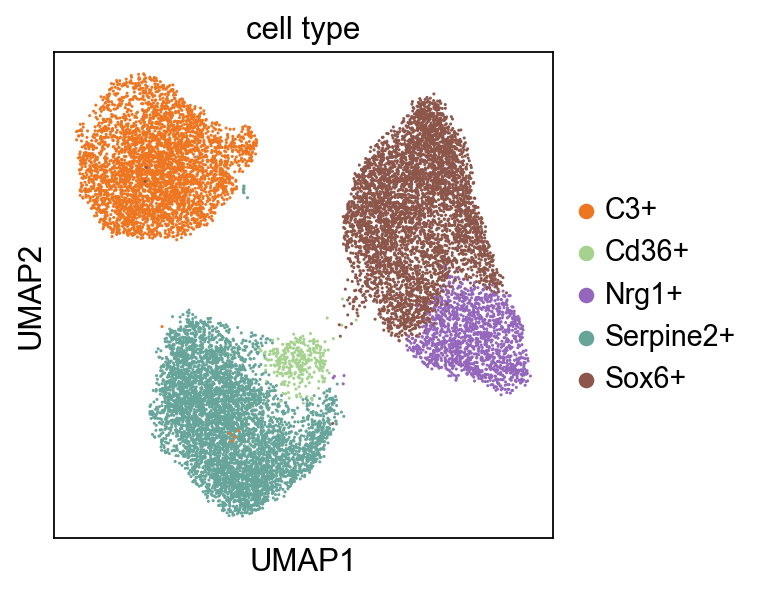

In [33]:
custom_palette = ['#EE7621','#A5D38F',   '#9467bd','#67A59B','#8c564b']
sc.pl.umap(adata, color='cell type',palette=custom_palette, save='celltype.pdf')

In [34]:
celltype_color_map = {
    "Sox6+": "#8c564b",
    "Nrg1+": "#9467bd",
    "C3+": "#EE7621",
    "Cd36+": "#A5D38F",
    "Serpine2+": "#67A59B",
}

adata.uns["cell type_colors"] = [
    celltype_color_map[x] for x in adata.obs["cell type"].cat.categories
]

In [35]:
genes = ["Cd81","Pcolce2", "C3", "Ebf1","Ackr4",'Pi16','Abca8a',
         "Lpl","Fgfr2", "Cd36", "Prrx2","Hcar2",  "Ces1g",  "Dnmt3l",'Ccl8',
         "Bmp2", "Rgs2",'Ccdc3','Cd82', "Nrg1",
     "Ednrb",  "Wnt5a", "Pla2g7", "Pla2g4a", "Ntf3",
     "Tnfsf13b","Serpina3n", "Serpine2", "Osr1","Ctgf",
     "Acta2", "Myl9", "Pdlim3",   "Tagln",
    "Thbd", "Rbp4", "Fibin",   "Bmp3",  "Sox6"
]



In [36]:
adata = adata.raw.to_adata()
sc.pp.scale(adata)

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


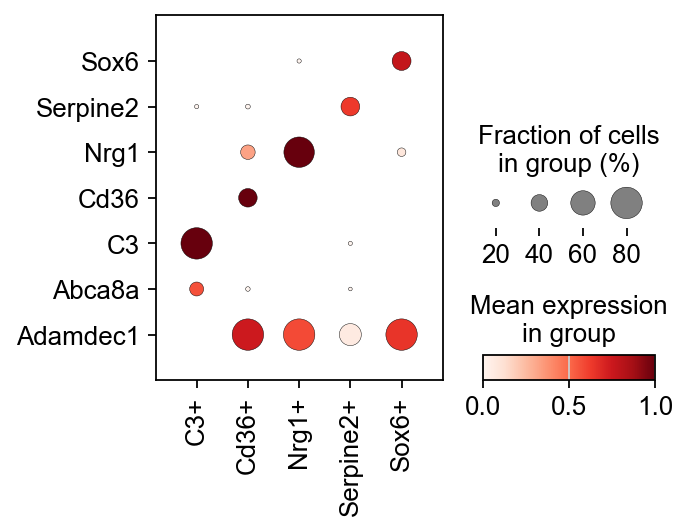

In [37]:
sc.pl.dotplot(adata, ['Sox6', 'Serpine2', 'Nrg1', 'Cd36', 'C3', 'Abca8a', 'Adamdec1'], groupby="cell type",
                   swap_axes=True,
                      dot_min=0.1,  
                     dot_max=0.8,   
                     vmin=0, 
                      figsize=(4, 3), 
                      vmax=1,save='cell_type_dopplot1223.pdf' )

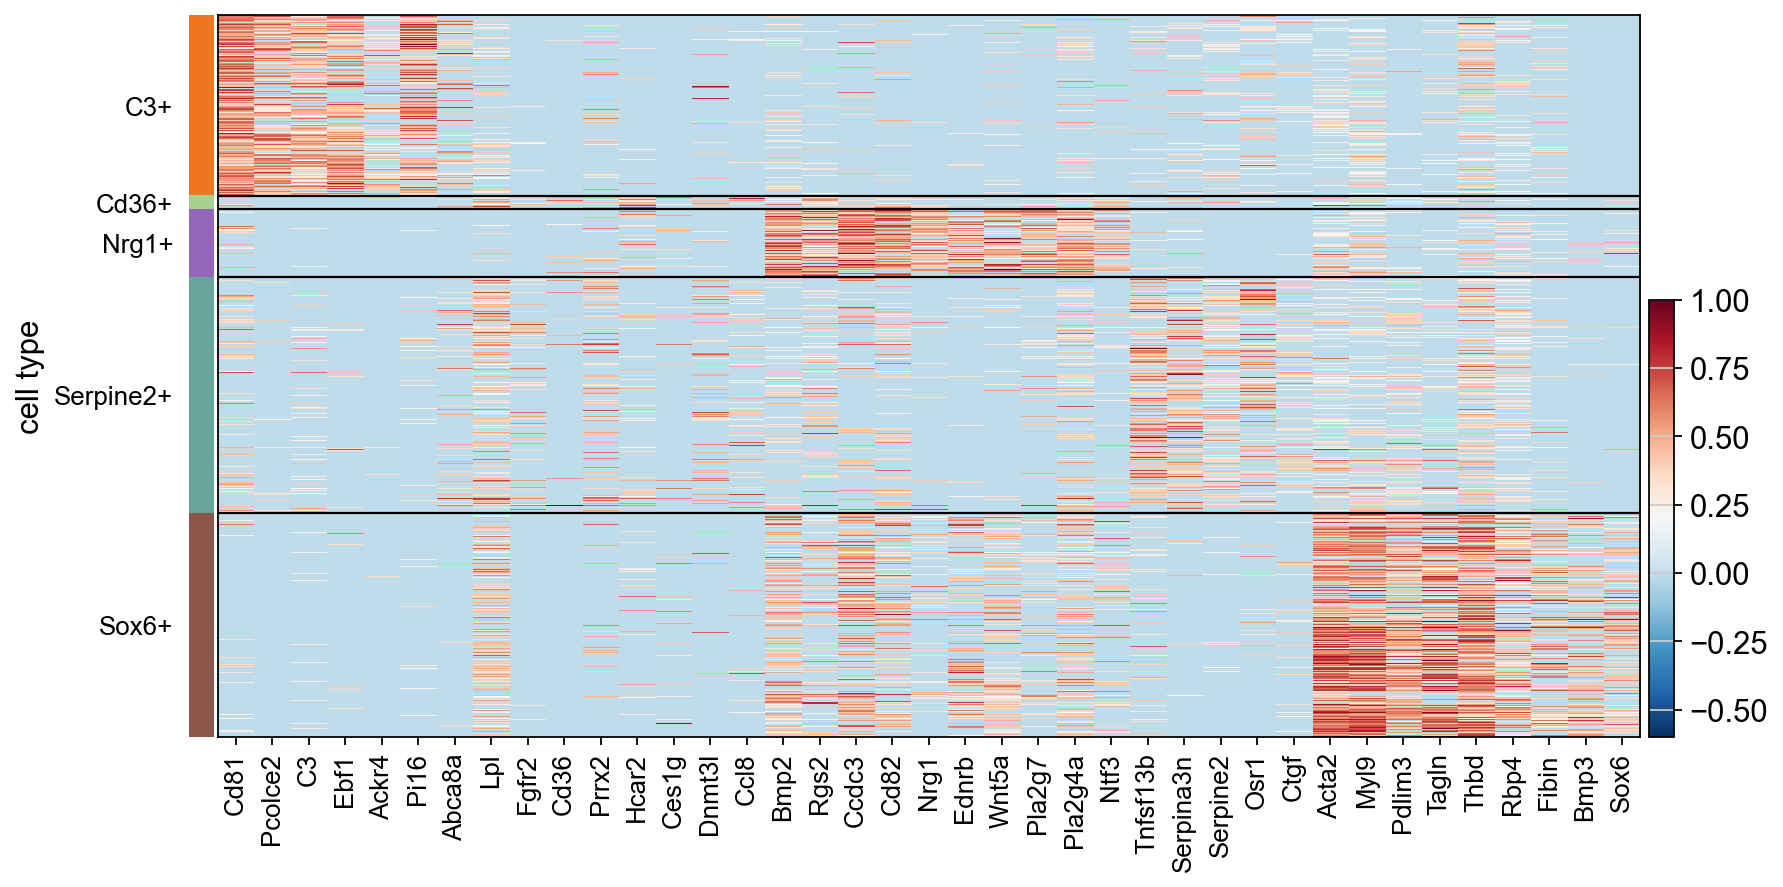

In [38]:
ax = sc.pl.heatmap(adata, genes, groupby='cell type',cmap='RdBu_r', show_gene_labels=True,var_group_rotation=45, standard_scale="var", vmin=-0.6, vmax=1,save='heatmap.pdf')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


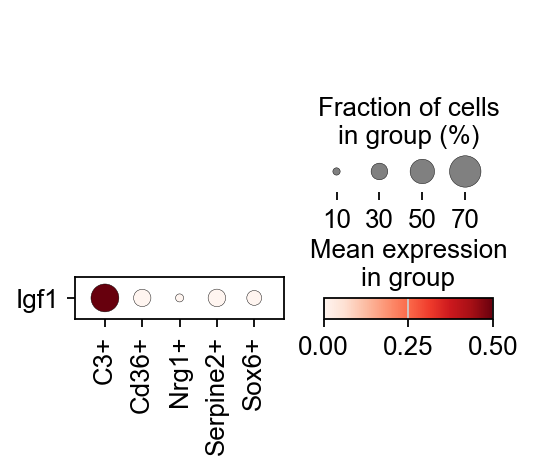

In [39]:
sc.pl.dotplot(adata, ['Igf1'], groupby="cell type",
                     dot_max=0.7, 
                     vmin=0, swap_axes=True,
                      vmax=0.5,
                      save='IGF1_dopplot.pdf' )

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


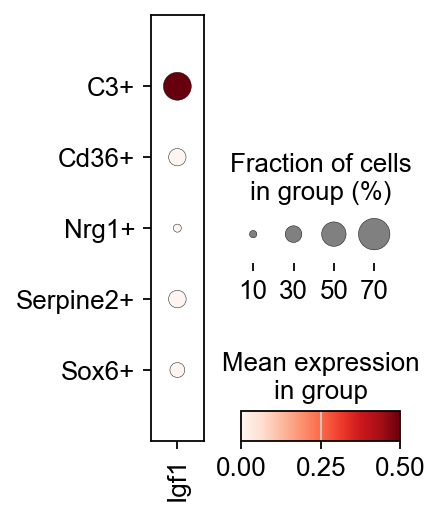

In [40]:
sc.pl.dotplot(adata, ['Igf1'], groupby="cell type",
                   swap_axes=False,
                     dot_max=0.7,  
                     vmin=0, 
                     figsize=(2, 3.5),
                      vmax=0.5,
                      save='IGF1_dopplot1223.pdf' )